In [1]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [13]:
# 2. Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Scaling for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Initialize models
models = {
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [14]:
# 6. Train, predict, and evaluate
results = []

for name, model in models.items():
    if "KNN" in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    print(f"\n{name}")
    print("Confusion Matrix:")
    print(cm)

# 7. Results table
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"]
)

print("\n=== Model Comparison ===")
results_df


KNN (k=5)
Confusion Matrix:
[[39  3]
 [ 2 70]]

Decision Tree
Confusion Matrix:
[[39  3]
 [ 7 65]]

Random Forest
Confusion Matrix:
[[39  3]
 [ 2 70]]

=== Model Comparison ===


,Model,Accuracy,Precision,Recall,F1-score
0,KNN (k=5),0.956140,0.958904,0.972222,0.965517
1,Decision Tree,0.912281,0.955882,0.902778,0.928571
2,Random Forest,0.956140,0.958904,0.972222,0.965517


In [7]:
# KNN Ablation Study
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

knn_results = []

k_values = [1, 3, 5, 7, 9, 11, 15, 21]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = knn.predict(X_train_scaled)
    y_test_pred = knn.predict(X_test_scaled)

    knn_results.append([
        k,
        # Train metrics
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),

        # Test metrics
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred)
    ])

knn_df = pd.DataFrame(
    knn_results,
    columns=[
        "n_neighbors",
        "Train Accuracy", "Train Precision", "Train Recall", "Train F1",
        "Test Accuracy", "Test Precision", "Test Recall", "Test F1"
    ]
)

knn_df

,n_neighbors,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,1,1.000000,1.000000,1.000000,1.000000,0.938596,0.957746,0.944444,0.951049
1,3,0.978022,0.972509,0.992982,0.982639,0.982456,0.972973,1.000000,0.986301
2,5,0.973626,0.969072,0.989474,0.979167,0.956140,0.958904,0.972222,0.965517
3,7,0.975824,0.969178,0.992982,0.980936,0.973684,0.960000,1.000000,0.979592
4,9,0.973626,0.969072,0.989474,0.979167,0.973684,0.960000,1.000000,0.979592
5,11,0.971429,0.965753,0.989474,0.977470,0.973684,0.960000,1.000000,0.979592
6,15,0.969231,0.962457,0.989474,0.975779,0.973684,0.960000,1.000000,0.979592
7,21,0.964835,0.952862,0.992982,0.972509,0.964912,0.947368,1.000000,0.972973


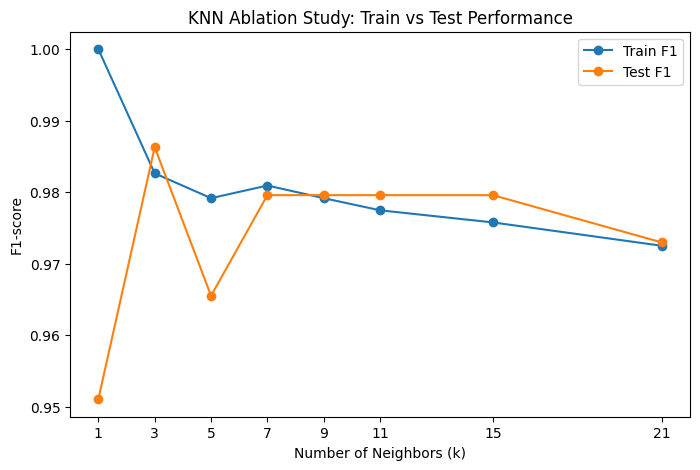

In [16]:
#KNN Ablation Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(knn_df["n_neighbors"], knn_df["Train F1"], marker="o", label="Train F1")
plt.plot(knn_df["n_neighbors"], knn_df["Test F1"], marker="o", label="Test F1")

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("F1-score")
plt.title("KNN Ablation Study: Train vs Test Performance")

# force integer ticks
plt.xticks(knn_df["n_neighbors"])
plt.legend()
plt.show()

In [17]:
# Decision Tree Ablation Study
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

dt_results = []
depth_values = [None, 2, 3, 4, 5, 6, 8, 10]

for depth in depth_values:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    dt_results.append([
        depth,
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred)
    ])

dt_df = pd.DataFrame(
    dt_results,
    columns=[
        "max_depth",
        "Train Accuracy", "Train Precision", "Train Recall", "Train F1",
        "Test Accuracy", "Test Precision", "Test Recall", "Test F1"
    ]
)

dt_df


,max_depth,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,NaN,1.000000,1.000000,1.000000,1.000000,0.912281,0.955882,0.902778,0.928571
1,2.0,0.958242,0.981884,0.950877,0.966132,0.894737,0.968750,0.861111,0.911765
2,3.0,0.975824,0.969178,0.992982,0.980936,0.938596,0.945205,0.958333,0.951724
3,4.0,0.986813,0.979381,1.000000,0.989583,0.938596,0.957746,0.944444,0.951049
4,5.0,0.993407,0.993007,0.996491,0.994746,0.921053,0.956522,0.916667,0.936170
5,6.0,0.997802,0.996503,1.000000,0.998249,0.912281,0.955882,0.902778,0.928571
6,8.0,1.000000,1.000000,1.000000,1.000000,0.912281,0.955882,0.902778,0.928571
7,10.0,1.000000,1.000000,1.000000,1.000000,0.912281,0.955882,0.902778,0.928571


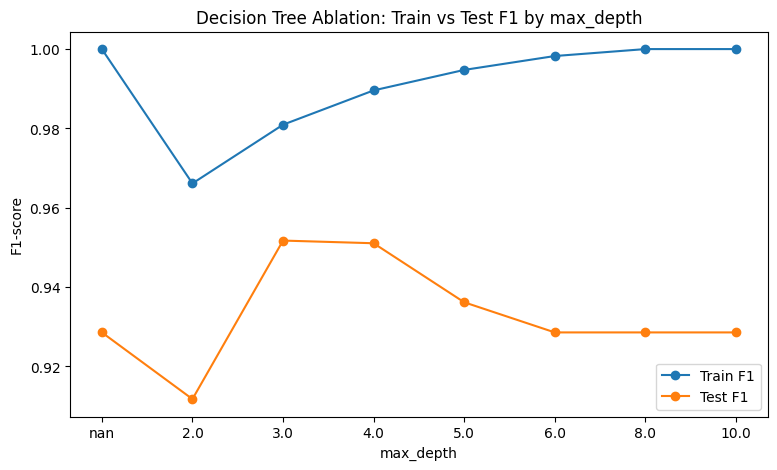

In [18]:
# Decision Tree Ablation Graph
import matplotlib.pyplot as plt

x = dt_df["max_depth"].astype(str)

plt.figure(figsize=(9,5))
plt.plot(x, dt_df["Train F1"], marker="o", label="Train F1")
plt.plot(x, dt_df["Test F1"], marker="o", label="Test F1")
plt.xlabel("max_depth")
plt.ylabel("F1-score")
plt.title("Decision Tree Ablation: Train vs Test F1 by max_depth")
plt.legend()
plt.show()

In [19]:
# Random Forest Ablation Study
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

rf_results = []
depth_values = [None, 2, 3, 4, 5, 6, 8, 10]

for depth in depth_values:
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )
    rf.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    rf_results.append([
        depth,
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred)
    ])

rf_df = pd.DataFrame(
    rf_results,
    columns=[
        "max_depth",
        "Train Accuracy", "Train Precision", "Train Recall", "Train F1",
        "Test Accuracy", "Test Precision", "Test Recall", "Test F1"
    ]
)

rf_df

,max_depth,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,NaN,1.000000,1.000000,1.000000,1.000000,0.956140,0.958904,0.972222,0.965517
1,2.0,0.964835,0.965398,0.978947,0.972125,0.947368,0.958333,0.958333,0.958333
2,3.0,0.980220,0.975862,0.992982,0.984348,0.956140,0.958904,0.972222,0.965517
3,4.0,0.993407,0.989583,1.000000,0.994764,0.956140,0.958904,0.972222,0.965517
4,5.0,0.993407,0.989583,1.000000,0.994764,0.956140,0.958904,0.972222,0.965517
5,6.0,0.995604,0.993031,1.000000,0.996503,0.947368,0.958333,0.958333,0.958333
6,8.0,1.000000,1.000000,1.000000,1.000000,0.956140,0.958904,0.972222,0.965517
7,10.0,1.000000,1.000000,1.000000,1.000000,0.956140,0.958904,0.972222,0.965517


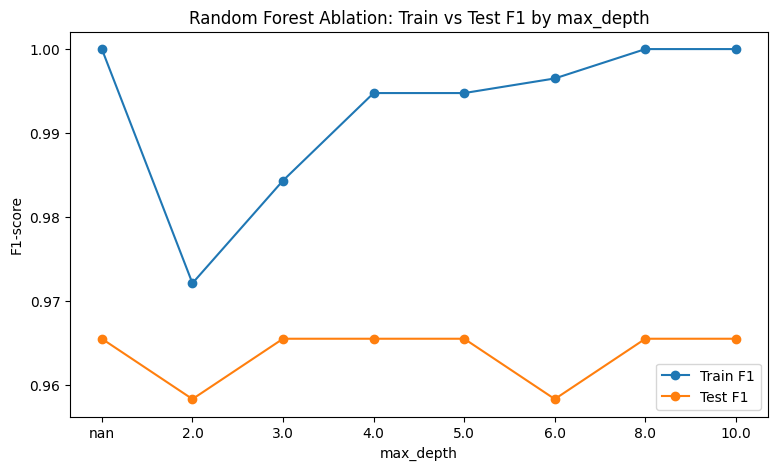

In [20]:
# Random Forest Ablation Graph
x = rf_df["max_depth"].astype(str)

plt.figure(figsize=(9,5))
plt.plot(x, rf_df["Train F1"], marker="o", label="Train F1")
plt.plot(x, rf_df["Test F1"], marker="o", label="Test F1")
plt.xlabel("max_depth")
plt.ylabel("F1-score")
plt.title("Random Forest Ablation: Train vs Test F1 by max_depth")
plt.legend()
plt.show()